# Logisit Regression

$ \hat{logit} = Xw $

$ \hat{p} = \sigma(\hat{logit}) $

$ \hat{y} = \begin{cases}0 , \hat{p} < 0.5 \\ 1, \hat{p} >= 0.5 \end{cases}$


$ odds =  \frac{p}{1-p}  \\logit = log \frac{p}{1-p}\\ \sigma(x) = \frac{1}{1+exp(-x)} \\ \sigma(logit) = p $


The shape of the function is S, so it is also called sigmoid.

### Cost Fuc
: log loss in classification

$ J_{oneData}(w) = \begin{cases} -log(\hat{p}), y=1 \\ -log(1-\hat{p}), y=0 \end{cases} $
> = $ - ( y log(\hat{p}) + (1-y)log(1-\hat{p})) $

>Optimization min(w)

> J(w) = $ - \sum({ylog(\hat{p}) +(1-y)log(1-\hat{p})} \\ \frac{\partial J(w)}{\partial w} = \frac{\partial J(w)}{\partial p} * \frac{\partial p}{\partial logit} * \frac{\partial logit}{\partial w} \\  = (p-y)x \\ w^{new} = w - lr * \frac{\partial} {\partial w}J(w)$

In [3]:
import numpy as np
import matplotlib.pyplot as plt

seed = 1234
np.random.seed(seed)

# make data
num_sample_per_class = 250

X_class1 = np.random.normal(2, 1, (num_sample_per_class,2))
X_class2 = np.random.normal(-2, 1, (num_sample_per_class,2))

X_ = np.vstack([X_class1, X_class2])
X = np.hstack([np.ones((num_sample_per_class * 2, 1)), X_])
y = np.array([1] * num_sample_per_class + [0] * num_sample_per_class)


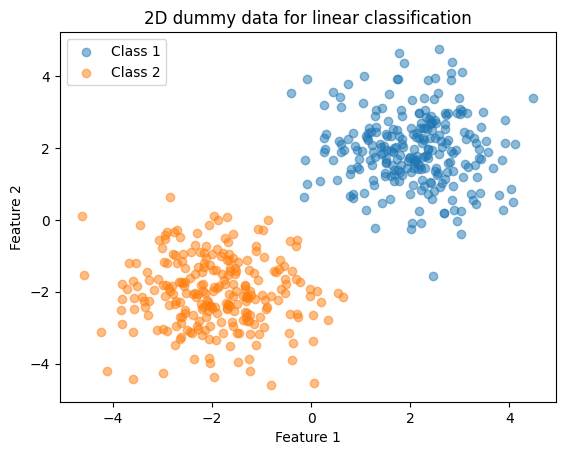

In [4]:
# plot

plt.scatter(X_class1[:, 0], X_class1[:, 1], alpha=0.5, label="Class 1")
plt.scatter(X_class2[:, 0], X_class2[:, 1], alpha=0.5, label="Class 2")

plt.title("2D dummy data for linear classification")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()

In [6]:
np.random.seed(seed)

def sigmoid(z):
  return 1 / (1 + np.exp(-z))

def log_loss(y, p):
  return -(y * np.log(p) + (1-y) * np.log(1-p))

def calc_logistic_SGD(X ,y, lr, epochs, init_params):
  N = len(y)
  y = y.reshape((-1, 1))
  for i in range(epochs):
    logit = X @ init_params

    p = sigmoid(logit)

    loss = log_loss(y, p)
    loss = loss.mean

    gradient = 1/N * X.T @ (p-y)

    init_params -= lr * gradient

  return init_params

init_params = np.random.randn(X.shape[1], 1)
lr = 0.01
epochs = 1000

params = calc_logistic_SGD(X, y, lr, epochs, init_params)
params

array([[0.31235342],
       [0.55925797],
       [2.11504038]])

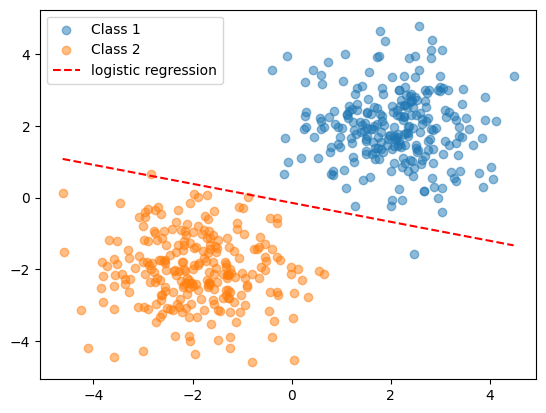

In [7]:
# plot

plt.scatter(X_class1[:, 0], X_class1[:, 1], alpha=0.5, label="Class 1")
plt.scatter(X_class2[:, 0], X_class2[:, 1], alpha=0.5, label="Class 2")

w0, w1, w2 = params.T[0]

feauter1_value = np.array([X[:, 1].min(), X[:, 1].max()])
feauter2_value = -(w0 + w1 * feauter1_value) / w2

plt.plot(feauter1_value, feauter2_value, color="red", linestyle="--",
         label="logistic regression")
plt.legend()


In [8]:
from sklearn.linear_model import SGDClassifier

sgd_clf = SGDClassifier()
sgd_clf.fit(X, y)

sgd_clf.coef_, sgd_clf.intercept_

(array([[0.        , 7.81467381, 8.87905919]]), array([-1.14237545]))

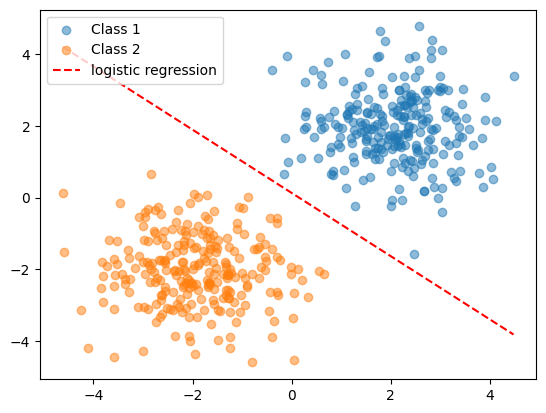

In [9]:
# plot

plt.scatter(X_class1[:, 0], X_class1[:, 1], alpha=0.5, label="Class 1")
plt.scatter(X_class2[:, 0], X_class2[:, 1], alpha=0.5, label="Class 2")

w0 = sgd_clf.intercept_[0]
w1, w2 = sgd_clf.coef_[0][1:]

feauter1_value = np.array([X[:, 1].min(), X[:, 1].max()])
feauter2_value = -(w0 + w1 * feauter1_value) / w2

plt.plot(feauter1_value, feauter2_value, color="red", linestyle="--",
         label="logistic regression")
plt.legend()
